# Big Data EDA

In [1]:
import os
import sys

root_dir = os.path.abspath("..")

if root_dir not in sys.path:
    sys.path.append(root_dir)

In [2]:
from database.db_config import db_connect
import numpy as np
import pandas as pd

conn = db_connect()
df = pd.read_sql_query("SELECT * FROM customers", conn, index_col="customer_id")
df.head()

Database connected successfully


C:\Users\Ashish\AppData\Local\Temp\ipykernel_32288\1254177186.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM customers", conn, index_col="customer_id")


,tenure,monthly_charges,contract,tech_support,churn
customer_id,,,,,
CUST-0000,52.0,110.0,Two year,Yes,No
CUST-0001,15.0,120.0,Month-to-month,Yes,Yes
CUST-0002,72.0,85.0,Two year,No,No
CUST-0003,61.0,120.0,Month-to-month,Yes,Yes
CUST-0004,21.0,95.0,Month-to-month,No,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, CUST-0000 to CUST-9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           9500 non-null   float64
 1   monthly_charges  9500 non-null   float64
 2   contract         10000 non-null  str    
 3   tech_support     10000 non-null  str    
 4   churn            10000 non-null  str    
dtypes: float64(2), str(3)
memory usage: 468.8+ KB


In [4]:
df.describe()

,tenure,monthly_charges
count,9500.000000,9500.000000
mean,36.452737,102.340000
std,20.767888,13.104453
min,1.000000,85.000000
25%,18.000000,90.000000
50%,36.000000,95.000000
75%,55.000000,115.000000
max,72.000000,120.000000


In [5]:
df.isna().sum()

tenure             500
monthly_charges    500
contract             0
tech_support         0
churn                0
dtype: int64

In [6]:
from sklearn.impute import SimpleImputer

simple_imputer = SimpleImputer()
imputed_cols = simple_imputer.fit_transform(df[["tenure", "monthly_charges"]])
df[["tenure", "monthly_charges"]] = imputed_cols
df.isna().sum()

tenure             0
monthly_charges    0
contract           0
tech_support       0
churn              0
dtype: int64

In [7]:
df.head()

,tenure,monthly_charges,contract,tech_support,churn
customer_id,,,,,
CUST-0000,52.0,110.0,Two year,Yes,No
CUST-0001,15.0,120.0,Month-to-month,Yes,Yes
CUST-0002,72.0,85.0,Two year,No,No
CUST-0003,61.0,120.0,Month-to-month,Yes,Yes
CUST-0004,21.0,95.0,Month-to-month,No,Yes


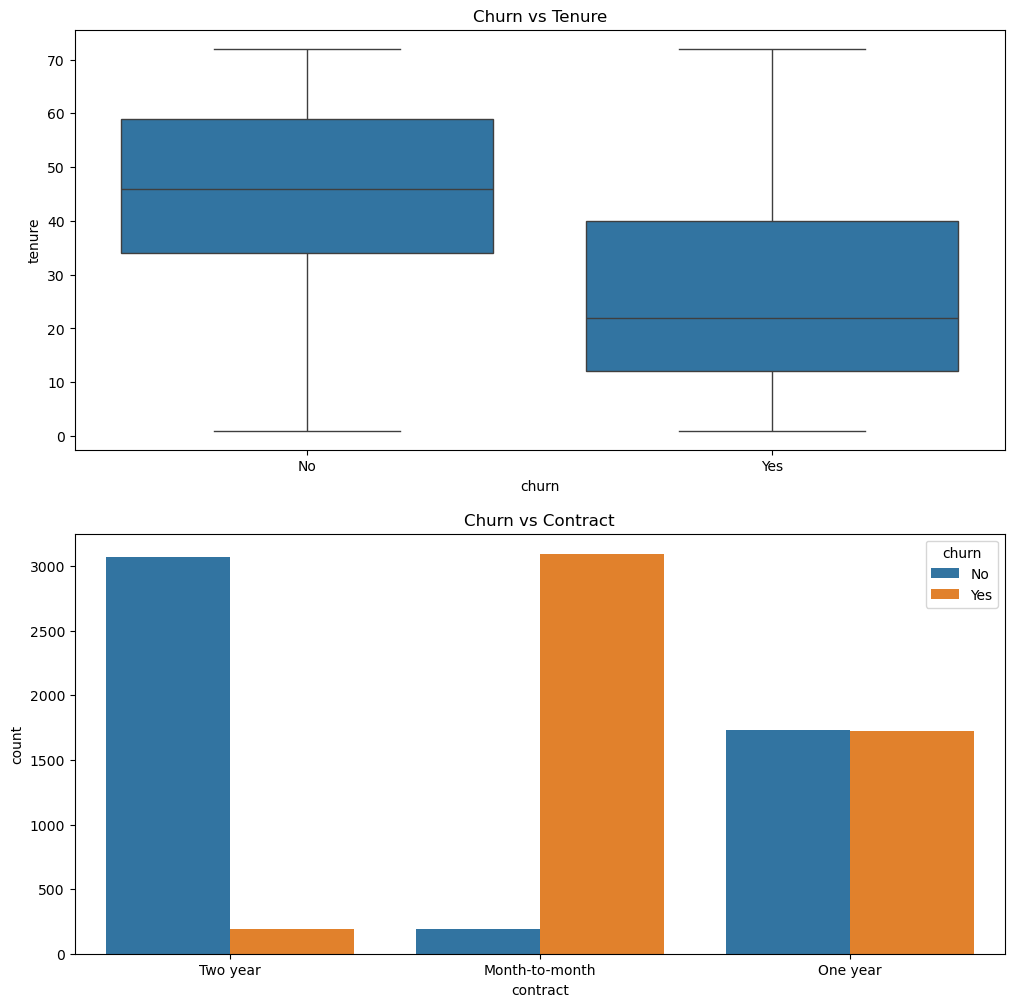

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,12))

plt.subplot(2,1,1)
sns.boxplot(x="churn", y="tenure", data=df)
plt.title("Churn vs Tenure")

plt.subplot(2,1,2)
sns.countplot(x="contract", hue="churn", data=df)
plt.title("Churn vs Contract")


plt.show()

In [9]:
bin_map = {"Yes" : 1, "No" : 0}
df["churn"] = df["churn"].map(bin_map)
df["tech_support"] = df["tech_support"].map(bin_map)
df.head()

,tenure,monthly_charges,contract,tech_support,churn
customer_id,,,,,
CUST-0000,52.0,110.0,Two year,1,0
CUST-0001,15.0,120.0,Month-to-month,1,1
CUST-0002,72.0,85.0,Two year,0,0
CUST-0003,61.0,120.0,Month-to-month,1,1
CUST-0004,21.0,95.0,Month-to-month,0,1


In [10]:
from sklearn.preprocessing import OneHotEncoder

one_hot = OneHotEncoder(sparse_output=False)
cat_cols = df.select_dtypes(include=[str]).columns
encoded_data = one_hot.fit_transform(df[cat_cols])
df_cat_encoded = pd.DataFrame(encoded_data, 
                              columns=one_hot.get_feature_names_out(cat_cols), 
                              index=df.index)

In [11]:
df_cat_encoded.head()

,contract_Month-to-month,contract_One year,contract_Two year
customer_id,,,
CUST-0000,0.0,0.0,1.0
CUST-0001,1.0,0.0,0.0
CUST-0002,0.0,0.0,1.0
CUST-0003,1.0,0.0,0.0
CUST-0004,1.0,0.0,0.0


In [12]:
df = pd.concat([df.drop(columns=cat_cols), df_cat_encoded], axis=1)
df.head()

,tenure,monthly_charges,tech_support,churn,contract_Month-to-month,contract_One year,contract_Two year
customer_id,,,,,,,
CUST-0000,52.0,110.0,1,0,0.0,0.0,1.0
CUST-0001,15.0,120.0,1,1,1.0,0.0,0.0
CUST-0002,72.0,85.0,0,0,0.0,0.0,1.0
CUST-0003,61.0,120.0,1,1,1.0,0.0,0.0
CUST-0004,21.0,95.0,0,1,1.0,0.0,0.0


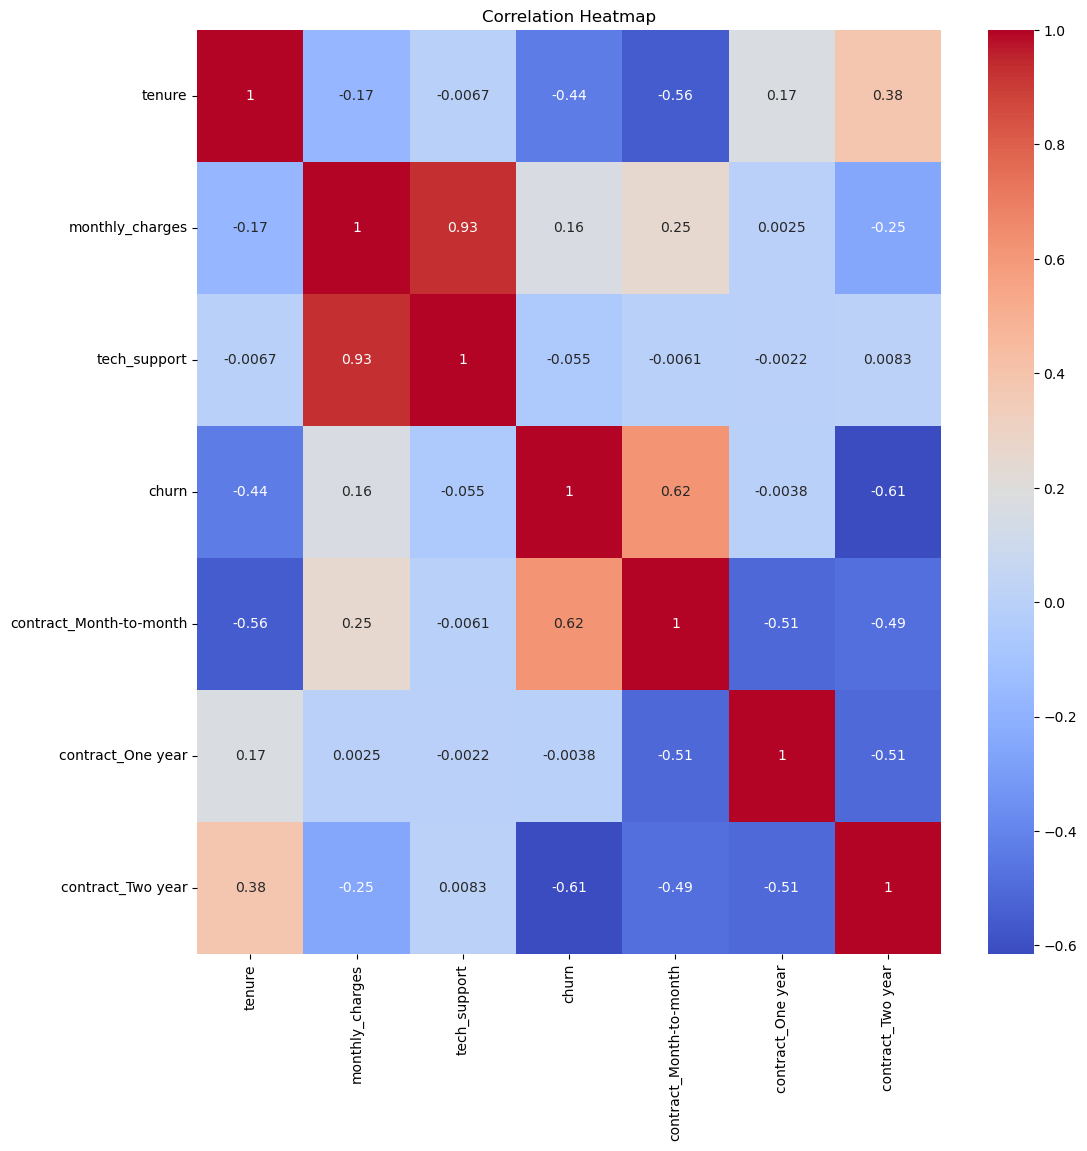

In [13]:
corr_matrix = df.corr()

plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df.head()

,tenure,monthly_charges,tech_support,churn,contract_Month-to-month,contract_One year,contract_Two year
customer_id,,,,,,,
CUST-0000,52.0,110.0,1,0,0.0,0.0,1.0
CUST-0001,15.0,120.0,1,1,1.0,0.0,0.0
CUST-0002,72.0,85.0,0,0,0.0,0.0,1.0
CUST-0003,61.0,120.0,1,1,1.0,0.0,0.0
CUST-0004,21.0,95.0,0,1,1.0,0.0,0.0


In [15]:
mm_cat = df["contract_Month-to-month"].copy()
mm_cat

customer_id
CUST-0000    0.0
CUST-0001    1.0
CUST-0002    0.0
CUST-0003    1.0
CUST-0004    1.0
            ... 
CUST-9995    0.0
CUST-9996    0.0
CUST-9997    0.0
CUST-9998    0.0
CUST-9999    1.0
Name: contract_Month-to-month, Length: 10000, dtype: float64

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

strata_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_i, test_i in strata_split.split(df, mm_cat):
    df_train = df.iloc[train_i].copy()
    df_test = df.iloc[test_i].copy()
    
print(df_train.info(), df_test.info())

<class 'pandas.DataFrame'>
Index: 8000 entries, CUST-8277 to CUST-6314
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tenure                   8000 non-null   float64
 1   monthly_charges          8000 non-null   float64
 2   tech_support             8000 non-null   int64  
 3   churn                    8000 non-null   int64  
 4   contract_Month-to-month  8000 non-null   float64
 5   contract_One year        8000 non-null   float64
 6   contract_Two year        8000 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 500.0+ KB
<class 'pandas.DataFrame'>
Index: 2000 entries, CUST-3710 to CUST-8903
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tenure                   2000 non-null   float64
 1   monthly_charges          2000 non-null   float64
 2   tech_support             2000 non-

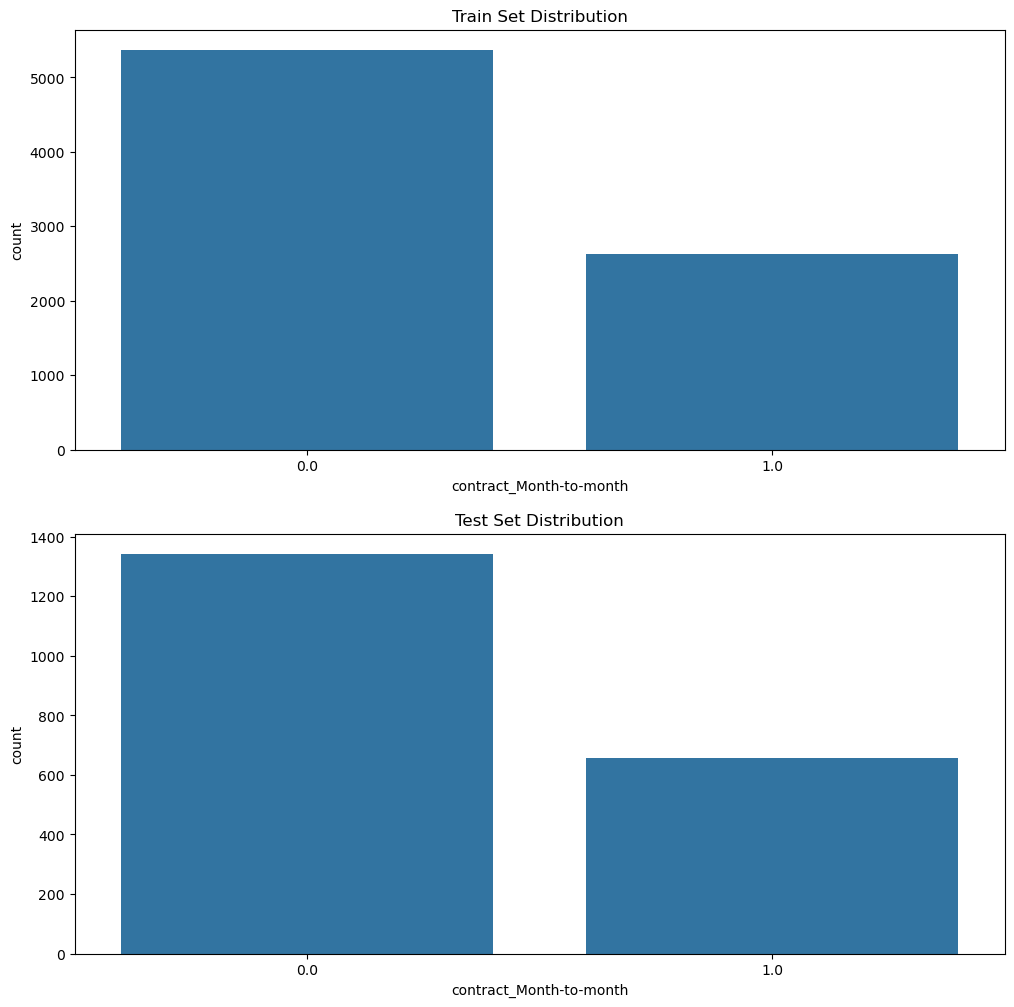

In [17]:
plt.figure(figsize=(12,12))

plt.subplot(2,1,1)
sns.countplot(x="contract_Month-to-month", data=df_train)
plt.title("Train Set Distribution")

plt.subplot(2,1,2)
sns.countplot(x="contract_Month-to-month", data=df_test)
plt.title("Test Set Distribution")

plt.show()

In [18]:
y_train = df_train["churn"].copy()
y_test = df_test["churn"].copy()
x_train = df_train.drop(columns=["churn"]).copy()
x_test = df_test.drop(columns=["churn"]).copy()
print(y_train.info(), y_test.info())

<class 'pandas.Series'>
Index: 8000 entries, CUST-8277 to CUST-6314
Series name: churn
Non-Null Count  Dtype
--------------  -----
8000 non-null   int64
dtypes: int64(1)
memory usage: 383.0+ KB
<class 'pandas.Series'>
Index: 2000 entries, CUST-3710 to CUST-8903
Series name: churn
Non-Null Count  Dtype
--------------  -----
2000 non-null   int64
dtypes: int64(1)
memory usage: 95.8+ KB
None None


In [19]:
print(x_train.info(),x_test.info())

<class 'pandas.DataFrame'>
Index: 8000 entries, CUST-8277 to CUST-6314
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tenure                   8000 non-null   float64
 1   monthly_charges          8000 non-null   float64
 2   tech_support             8000 non-null   int64  
 3   contract_Month-to-month  8000 non-null   float64
 4   contract_One year        8000 non-null   float64
 5   contract_Two year        8000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 695.5+ KB
<class 'pandas.DataFrame'>
Index: 2000 entries, CUST-3710 to CUST-8903
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tenure                   2000 non-null   float64
 1   monthly_charges          2000 non-null   float64
 2   tech_support             2000 non-null   int64  
 3   contract_Month-to-month  2000 non-

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train, y_train)

rand_for = RandomForestClassifier(oob_score=True, random_state=42)
rand_for.fit(x_train, y_train)

dec_tree = DecisionTreeClassifier()
dec_tree.fit(x_train, y_train)

# Predictions
log_reg_pred = log_reg.predict(x_train)
rand_for_pred = rand_for.predict(x_train)
dec_tree_pred = dec_tree.predict(x_train)

# Accuracy
log_reg_e = cross_val_score(
    log_reg,
    x_train,
    y_train,
    scoring="accuracy",
    cv=10
)
rand_for_e = cross_val_score(
    rand_for,
    x_train,
    y_train,
    scoring="accuracy",
    cv=10
)
dec_tree_e = cross_val_score(
    dec_tree,
    x_train,
    y_train,
    scoring="accuracy",
    cv=10
)

In [21]:
print("Logistic Reg", log_reg_e)
print("Random Forest", rand_for_e)
print("Decision Tree", dec_tree_e)

Logistic Reg [0.8275  0.81125 0.82625 0.78    0.7925  0.79375 0.7825  0.81125 0.79875
 0.805  ]
Random Forest [0.81125 0.79625 0.835   0.79875 0.79    0.77875 0.79875 0.79375 0.77375
 0.80375]
Decision Tree [0.81    0.78625 0.835   0.795   0.79    0.77    0.8     0.79375 0.785
 0.79625]


In [22]:
print("Logistic Reg :", log_reg_e.mean())
print("Random Forest :", rand_for_e.mean())
print("Decision Tree :", dec_tree_e.mean())

Logistic Reg : 0.802875
Random Forest : 0.7979999999999999
Decision Tree : 0.796125


In [23]:
from sklearn.model_selection import GridSearchCV

dec_tree_grid = {
    'max_depth' : [None, 10, 20, 30]
}

rand_for_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10]
}

dec_tree_grid_search = GridSearchCV(
    estimator=dec_tree,
    param_grid=dec_tree_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

rand_for_grid_search = GridSearchCV(
    estimator=rand_for,
    param_grid=rand_for_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

In [24]:
dec_tree_grid_search.fit(x_train, y_train)
rand_for_grid_search.fit(x_train, y_train)
print(f"For Decision Tree : {dec_tree_grid_search.best_score_} and {dec_tree_grid_search.best_params_}")
print(f"For Random Forest : {rand_for_grid_search.best_score_} and {rand_for_grid_search.best_params_}")

For Decision Tree : 0.79925 and {'max_depth': 10}
For Random Forest : 0.80625 and {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  
    'penalty': ['l1', 'l2'],              
    'solver': ['liblinear', 'saga']       
}

grid_search_lr = GridSearchCV(
    estimator=log_reg, 
    param_grid=param_grid_lr, 
    cv=5, 
    scoring='accuracy'
    )
grid_search_lr.fit(x_train, y_train)

print(f"For Logistic Reggression : {grid_search_lr.best_score_} and {grid_search_lr.best_params_}")